# Simple Separation Experiments

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import snag
from scipy.spatial.distance import pdist, squareform

In [11]:
calc = snag.Hubbard(n_up=1, n_dn=1, n_sites=2)
doubles = calc.doubles()

for i, j in zip(doubles, calc.basis):
    print(i, j.flatten())

1 [1 0 1 0]
0 [1 0 0 1]
0 [0 1 1 0]
1 [0 1 0 1]


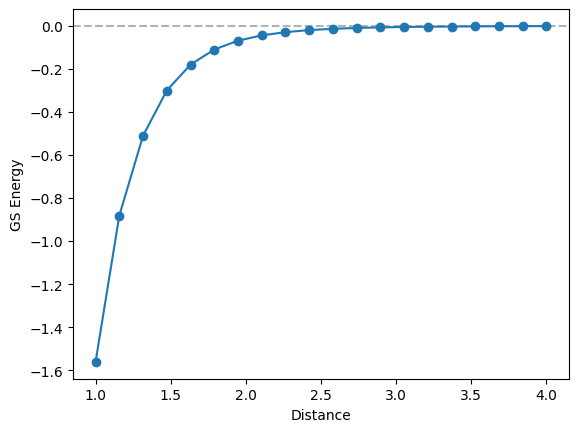

In [15]:
calc_mol = snag.HubbardMol(calc)

separations = np.linspace(1.0, 4.0, 20)
energies = [calc_mol.solve(sep) for sep in separations]

plt.axhline(y=0, ls='--', c='k', alpha=0.3)
plt.plot(separations, energies, marker="o")
plt.xlabel("Distance")
plt.ylabel("GS Energy")
plt.show()

In [63]:
# 2*n chain bisection
n_chain = 10

ni_hoppings = squareform(
    snag.hubbard_mol.radial_hopping(pdist(np.arange(n_chain//2)[:, None]))
    )
non_int = snag.NonInteracting(ni_hoppings)
benchmark = 2*non_int.total_energy(1, 0)

calc = snag.Hubbard(n_up=1, n_dn=1, n_sites=n_chain)
calc_mol = snag.HubbardMol(calc)

distortions = np.linspace(0., 4., 20)
energies = []

for d in distortions:
    x = np.arange(n_chain, dtype=float)
    x[n_chain//2:] = x[n_chain//2:] + d
    pds = pdist(x[:, None])
    energies.append(calc_mol.solve(pds))

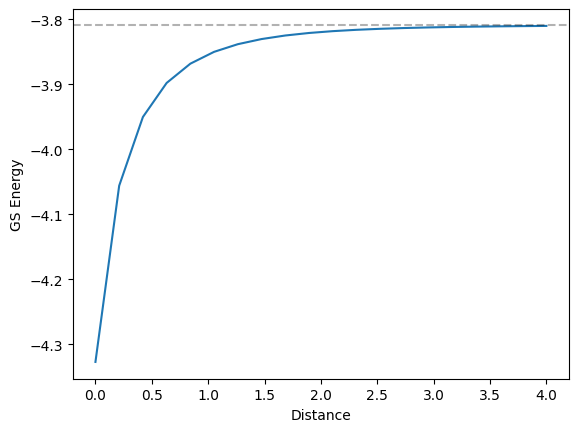

In [64]:
plt.plot(distortions, energies)

plt.axhline(y=benchmark, ls='--', c='k', alpha=0.3)
plt.xlabel("Distance")
plt.ylabel("GS Energy")
plt.show()